In [1]:
import os
from dotenv import load_dotenv

from langgraph.graph import StateGraph, START, END

from langchain_ollama import ChatOllama

from typing import TypedDict, Annotated

from langchain_core.messages import BaseMessage, HumanMessage

from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver

load_dotenv()

True

In [2]:
ollama_gpt = ChatOllama(model='gpt-oss:120b-cloud')

In [3]:
class ChatState(TypedDict):
    topic: str
    jokes: str
    explanation: str

def generate_jokes(state: ChatState)-> ChatState:

    prompt = f"generate a joke on the following {state['topic']}"

    response = ollama_gpt.invoke(prompt)

    return {'jokes': response.content}

def generate_explanation(state: ChatState)->ChatState:

    prompt = f"generate an explanation for the joke: \n{state['jokes']}"

    response = ollama_gpt.invoke(prompt)

    return {'explanation': response.content}

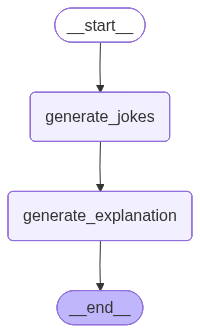

In [4]:
graph = StateGraph(ChatState)

graph.add_node('generate_jokes',generate_jokes)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_jokes')
graph.add_edge('generate_jokes','generate_explanation')
graph.add_edge('generate_explanation',END)

check_pointer = InMemorySaver()

generator = graph.compile(checkpointer=check_pointer)

generator

In [5]:
initial_state = {
    'topic':'Cat'
}

config = {'configurable': {'thread_id': '1'}}
generator.invoke(initial_state,config=config)

{'topic': 'Cat',
 'jokes': 'Why did the cat sit on the computer?\n\nBecause it wanted to keep an eye on the mouse while “pawsing” the internet! 🐾😹',
 'explanation': '**Why the joke works – a step‑by‑step breakdown**\n\n| Element of the joke | What it literally means | Why it’s funny (the wordplay or cultural reference) |\n|----------------------|-------------------------|---------------------------------------------------|\n| **Cat** | A domestic animal that loves to curl up on warm surfaces. | Cats are famously curious about anything that moves—especially tiny, squeaky things like a *mouse* (the real rodent). |\n| **Computer** | An electronic device for processing information, typically with a keyboard, monitor, and a **mouse** (the hand‑held pointing device). | The word *mouse* now has two meanings: the animal and the computer peripheral. The joke exploits that double meaning. |\n| **“Keep an eye on the mouse”** | Literally: watch a real mouse. In computer terms: watch the cursor (th

In [6]:
for chunk in generator.get_state(config)[0]['explanation'].split('\n'):
    print(chunk)

**Why the joke works – a step‑by‑step breakdown**

| Element of the joke | What it literally means | Why it’s funny (the wordplay or cultural reference) |
|----------------------|-------------------------|---------------------------------------------------|
| **Cat** | A domestic animal that loves to curl up on warm surfaces. | Cats are famously curious about anything that moves—especially tiny, squeaky things like a *mouse* (the real rodent). |
| **Computer** | An electronic device for processing information, typically with a keyboard, monitor, and a **mouse** (the hand‑held pointing device). | The word *mouse* now has two meanings: the animal and the computer peripheral. The joke exploits that double meaning. |
| **“Keep an eye on the mouse”** | Literally: watch a real mouse. In computer terms: watch the cursor (the on‑screen “mouse”). | The cat’s natural instinct to hunt a real mouse is juxtaposed with the modern “mouse” that sits on the desk. The image of a cat monitoring a cursor 

In [15]:
initial_state = {'topic':HumanMessage(content='Narendra Modi')}

config = {'configurable': {'thread_id': '2'}}
generator.invoke(initial_state,config=config)

{'topic': HumanMessage(content='Narendra Modi', additional_kwargs={}, response_metadata={}),
 'jokes': 'Why did Narendra\u202fModi bring a broom to the parliament?\n\nBecause he heard the opposition was planning a “clean sweep” and wanted to make sure the floor was already spotless! 😄',
 'explanation': '**Why the joke works**\n\n1. **The phrase “clean sweep” has two meanings**  \n   - *Political jargon*: When a party wins every seat or a large number of seats in an election, commentators say it achieved a “clean sweep.”  \n   - *Literal cleaning*: A “sweep” is what you do with a broom to make a floor spotless.\n\n2. **Linking the two meanings**  \n   The joke imagines Narendra\u202fModi (India’s Prime Minister) taking the phrase literally. He thinks the opposition’s talk of a “clean sweep” means they intend to physically sweep the parliamentary floor, so he brings a broom to be ready.\n\n3. **Why the humour lands**  \n   - **Surprise**: Listeners expect a political punch‑line, but the 

In [16]:
list(generator.get_state_history(config))

[StateSnapshot(values={'topic': HumanMessage(content='Narendra Modi', additional_kwargs={}, response_metadata={}), 'jokes': 'Why did Narendra\u202fModi bring a broom to the parliament?\n\nBecause he heard the opposition was planning a “clean sweep” and wanted to make sure the floor was already spotless! 😄', 'explanation': '**Why the joke works**\n\n1. **The phrase “clean sweep” has two meanings**  \n   - *Political jargon*: When a party wins every seat or a large number of seats in an election, commentators say it achieved a “clean sweep.”  \n   - *Literal cleaning*: A “sweep” is what you do with a broom to make a floor spotless.\n\n2. **Linking the two meanings**  \n   The joke imagines Narendra\u202fModi (India’s Prime Minister) taking the phrase literally. He thinks the opposition’s talk of a “clean sweep” means they intend to physically sweep the parliamentary floor, so he brings a broom to be ready.\n\n3. **Why the humour lands**  \n   - **Surprise**: Listeners expect a political 

In [20]:
type(generator.get_state(config).values['topic'])

langchain_core.messages.human.HumanMessage